# Dataset Inspection: dataset-labeled-anon-ip.csv

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH = '../../../../data/cscas/dataset-labeled-anon-ip.csv'

## 1. Load & Basic Info

In [166]:
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

# Per-attribute similarity columns (Tls*, Http*, Dns*, ...) -- everything
# ending in "Similarity" except the aggregate `Similarity`/`SCAS` columns,
# which sections 7/8 already treat separately (see corr_cols below).
sim_cols = [c for c in df.columns if c.endswith('Similarity') and c != 'Similarity']
print(f'{len(sim_cols)} per-attribute similarity columns')

Shape: (1395324, 47)
Memory: 766.7 MB
34 per-attribute similarity columns


## 3. Label Distribution

In [167]:
print('Label value counts:')
print(df['Label'].value_counts())
print(f'\nClass balance: {df["Label"].value_counts(normalize=True).round(4).to_dict()}')

Label value counts:
Label
0    1374372
1      20952
Name: count, dtype: int64

Class balance: {0: 0.985, 1: 0.015}


In [168]:
print('SCAS value counts:')
print(df['SCAS'].value_counts())

SCAS value counts:
SCAS
0    1322652
1      72672
Name: count, dtype: int64


### Dataset overview

Simple whole-dataset statistics for the EDA write-up: timespan, group / alert counts
and class split, and the cardinality + sentinel (`-1`, multi-valued) rate of each
categorical field. `to_latex` at the end emits a copy-pasteable version. The
per-signature / per-class breakdown is in the signature-behaviour summary below.

In [169]:
import re

n = len(df); n_att = int((df.Label == 1).sum())
raw = df.groupby('Label')['AlertCount'].sum()
cves = set()
for t in df.SignatureText.dropna().unique():
    cves.update(re.findall(r'CVE[-_]\d{4}[-_]\d+', t, flags=re.I))

# --- whole-dataset overview (vertical key/value) ---
rows = {
    'Collection window': f"{df.Timestamp.min():%Y-%m-%d} -- {df.Timestamp.max():%Y-%m-%d} "
                         f"({(df.Timestamp.max() - df.Timestamp.min()).days} days)",
    'Alert groups': f"{n:,}",
    '  benign groups': f"{n - n_att:,} ({(n - n_att) / n:.2%})",
    '  attack groups': f"{n_att:,} ({n_att / n:.2%})",
    'Underlying alerts (sum AlertCount)': f"{raw.sum():,}",
    '  benign alerts': f"{raw[0]:,} ({raw[0] / raw.sum():.2%})",
    '  attack alerts': f"{raw[1]:,} ({raw[1] / raw.sum():.2%})",
    'Mean AlertCount (benign / attack)': f"{df.loc[df.Label == 0, 'AlertCount'].mean():.1f} / "
                                        f"{df.loc[df.Label == 1, 'AlertCount'].mean():.1f}",
    'Distinct signatures': f"{df.SignatureID.nunique():,}",
    'Distinct CVE references': f"{len(cves):,}",
}
dataset_overview_tbl = pd.DataFrame({'Value': rows})

# --- categorical field cardinality (distinct / single-valued / multi-valued) ---
field_rows = []
for col, label in [('Proto', 'Protocol'), ('IntIP', 'Internal IP'), ('ExtIP', 'External IP'),
                   ('IntPort', 'Internal port'), ('ExtPort', 'External port')]:
    s = df[col].astype(str); mv = s.eq('-1'); sv = ~mv
    field_rows.append({
        'Field': label,
        'Distinct values': f"{s[sv].nunique():,}",
        'Single-valued rows': f"{sv.sum():,} ({sv.mean():.2%})",
        'Multi-valued rows': f"{mv.sum():,} ({mv.mean():.3%})",
    })
field_cardinality_tbl = pd.DataFrame(field_rows).set_index('Field')

display(dataset_overview_tbl)
display(field_cardinality_tbl)
print(dataset_overview_tbl.to_latex(caption='Overview statistics for the CSCAS data set.',
                                    label='tab:cscas-overview'))
print(field_cardinality_tbl.to_latex(caption='Categorical field cardinality in the CSCAS data set. '
                                     'Multi-valued rows carry the -1 sentinel (the alert group spans more '
                                     'than one distinct value).', label='tab:cscas-composition'))


,Value
Collection window,2022-01-20 -- 2022-03-20 (59 days)
Alert groups,"1,395,324"
benign groups,"1,374,372 (98.50%)"
attack groups,"20,952 (1.50%)"
Underlying alerts (sum AlertCount),"11,598,649"
benign alerts,"11,511,972 (99.25%)"
attack alerts,"86,677 (0.75%)"
Mean AlertCount (benign / attack),8.4 / 4.1
Distinct signatures,587
Distinct CVE references,116


,Distinct values,Single-valued rows,Multi-valued rows
Field,,,
Protocol,3,"1,395,195 (99.99%)",129 (0.009%)
Internal IP,"4,401","1,064,972 (76.32%)","330,352 (23.676%)"
External IP,"45,339","1,395,324 (100.00%)",0 (0.000%)
Internal port,"32,122","1,318,797 (94.52%)","76,527 (5.485%)"
External port,"64,592","1,157,943 (82.99%)","237,381 (17.013%)"


\begin{table}
\caption{Overview statistics for the CSCAS data set.}
\label{tab:cscas-overview}
\begin{tabular}{ll}
\toprule
 & Value \\
\midrule
Collection window & 2022-01-20 -- 2022-03-20 (59 days) \\
Alert groups & 1,395,324 \\
  benign groups & 1,374,372 (98.50%) \\
  attack groups & 20,952 (1.50%) \\
Underlying alerts (sum AlertCount) & 11,598,649 \\
  benign alerts & 11,511,972 (99.25%) \\
  attack alerts & 86,677 (0.75%) \\
Mean AlertCount (benign / attack) & 8.4 / 4.1 \\
Distinct signatures & 587 \\
Distinct CVE references & 116 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Categorical field cardinality in the CSCAS data set. Multi-valued rows carry the -1 sentinel (the alert group spans more than one distinct value).}
\label{tab:cscas-composition}
\begin{tabular}{llll}
\toprule
 & Distinct values & Single-valued rows & Multi-valued rows \\
Field &  &  &  \\
\midrule
Protocol & 3 & 1,395,195 (99.99%) & 129 (0.009%) \\
Internal IP & 4,401 & 1,064,972 (76.32%) 

**CVEs by class.** The 116 CVE references above are counted at the signature
level (distinct CVE strings across all `SignatureText` values); this breaks that
down by which class(es) the signatures mentioning each CVE belong to, and by
how many alert groups actually carry a CVE-mentioning signature.

In [ ]:
cve_pat = re.compile(r'CVE[-_]\d{4}[-_]\d+', re.I)
sig_lab = df.groupby('SignatureID')['Label'].agg(lambda s: set(s))
sig_cls_cve = sig_lab.apply(lambda s: 'mixed' if len(s) > 1 else ('attack' if 1 in s else 'benign'))
sig_text = (df[['SignatureID', 'SignatureText']].drop_duplicates('SignatureID')
            .set_index('SignatureID')['SignatureText'])

cve_classes = {}
for sid, text in sig_text.items():
    if pd.isna(text):
        continue
    for cve in cve_pat.findall(text):
        cve = cve.upper().replace('_', '-')
        cve_classes.setdefault(cve, set()).add(sig_cls_cve.loc[sid])

benign_only_cves = sorted(c for c, s in cve_classes.items() if s == {'benign'})
attack_only_cves = sorted(c for c, s in cve_classes.items() if s == {'attack'})
shared_cves = sorted(c for c, s in cve_classes.items() if len(s) > 1)

print(f'{len(cve_classes)} distinct CVEs across {sig_text.notna().sum()} signatures')
print(f'  benign-only : {len(benign_only_cves)}')
print(f'  attack-only : {len(attack_only_cves)}')
print(f'  both classes: {len(shared_cves)}  {shared_cves}')

# Alert-group-level: how many groups actually carry a CVE-mentioning signature
has_cve = df['SignatureText'].fillna('').str.contains(cve_pat)
grp_counts = df.loc[has_cve].groupby('Label').size().rename({0: 'benign', 1: 'attack'})
print(f'\nalert groups with a CVE-mentioning signature: {has_cve.sum():,} of {len(df):,}')
print(grp_counts.to_string())


## 4. Temporal Coverage

In [170]:
print(f'Time range: {df["Timestamp"].min()} → {df["Timestamp"].max()}')
print(f'Duration: {df["Timestamp"].max() - df["Timestamp"].min()}')

Time range: 2022-01-20 00:00:03+02:00 → 2022-03-20 23:59:58+02:00
Duration: 59 days 23:59:55


In [ ]:
BIN = '12h'
vol = df.set_index('Timestamp').resample(BIN).agg(
    total=('Label', 'count'),
    attacks=('Label', lambda x: (x == 1).sum()),
)

# Global class of each signature (the label set it has ever appeared with).
# CSCAS has 0 mixed signatures, but keep the category so the code is general.
sig_labels = df.groupby('SignatureID')['Label'].agg(lambda s: set(s))
sig_class = sig_labels.apply(
    lambda s: 'mixed' if len(s) > 1 else ('attack' if 1 in s else 'benign')
)
df['sig_class'] = df['SignatureID'].map(sig_class)

# Count of distinct signatures active per bucket, split by class -- computed on
# the SAME 12h grid as `vol` (previously daily counts were reindexed onto the
# 12h grid, which zero-filled every other bar).
sig_ct = (
    df.groupby([pd.Grouper(key='Timestamp', freq=BIN), 'sig_class'])['SignatureID']
      .nunique()
      .unstack('sig_class', fill_value=0)
      .reindex(columns=['benign', 'attack', 'mixed'], fill_value=0)
      .reindex(vol.index, fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 4))
ax2 = ax.twinx()

bar_kwargs = dict(width=0.5, alpha=0.35, linewidth=0)  # 0.5 day = one 12h bin
ax2.bar(sig_ct.index, sig_ct['benign'], label='Benign-only signatures',
        color='tab:blue', **bar_kwargs)
ax2.bar(sig_ct.index, sig_ct['attack'], bottom=sig_ct['benign'],
        label='Attack-only signatures', color='tab:red', **bar_kwargs)
ax2.set_ylabel('# distinct signatures active / bin')

# keep the alert-volume lines drawn on top of the bars
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.plot(vol.index, vol['total'], label='Total alerts', linewidth=0.8, color='dimgray')
ax.plot(vol.index, vol['attacks'], label='Attack alerts (Label=1)', linewidth=0.8, color='tab:red')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.set_title('CSCAS alert volume (12h bins, log scale) with count of distinct '
             'signatures active per bin, stacked by class')
ax.set_ylabel('# alerts')
ax.set_yscale('log')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The stacked bars above are a *count* of distinct signatures per bin -- they cannot
distinguish a stable vocabulary from one that churns (100 active today vs 100 active
tomorrow look identical whether they are the same 100 or disjoint). The companion
figure below shows churn directly: (a) cumulative distinct signatures ever seen vs
time -- a curve that keeps rising means new signatures keep arriving, flattening
means the vocabulary has saturated; (b) per-bin split of active signatures into
first-ever appearances vs previously-seen.

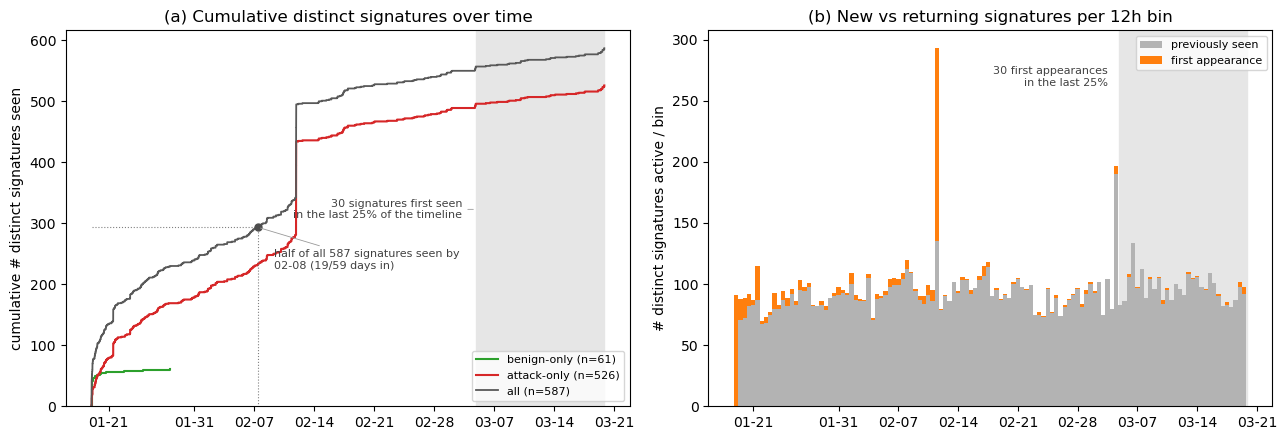

587 distinct signatures total; half first seen by 2022-02-08 (19/59 days in)
signatures first appearing in the last 25% of the timeline: 30


In [ ]:
# Signature-vocabulary churn: does the active set keep turning over, or saturate?
first_seen = df.groupby('SignatureID')['Timestamp'].min()
fs = first_seen.to_frame('first_seen')
fs['sig_class'] = sig_class.reindex(fs.index)

alls = fs['first_seen'].sort_values()
n_total = len(alls)
t0, t1 = alls.iloc[0], alls.iloc[-1]
span_days = (t1 - t0).days
half_date = alls.iloc[n_total // 2]
half_days_in = (half_date - t0).days
last25_start = t0 + 0.75 * (t1 - t0)
n_last25 = int((alls > last25_start).sum())

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) cumulative distinct signatures ever seen
for cls, color in [('benign', 'tab:blue'), ('attack', 'tab:red')]:
    s = fs.loc[fs.sig_class == cls, 'first_seen'].sort_values()
    axA.step(s.values, np.arange(1, len(s) + 1), where='post', color=color,
             label=f'{cls}-only (n={len(s)})')
axA.step(alls.values, np.arange(1, n_total + 1), where='post', color='0.35', lw=1.3,
         label=f'all (n={n_total})')

# shade the last 25% of the timeline + count first appearances in it
axA.axvspan(last25_start, t1, color='0.9', zorder=0)
axA.annotate(f'{n_last25} signatures first seen\nin the last 25% of the timeline',
             xy=(last25_start, n_total * 0.55), xytext=(-10, 0), textcoords='offset points',
             ha='right', va='center', fontsize=8, color='0.25',
             arrowprops=dict(arrowstyle='-', color='0.6', lw=0.6))

# mark the half-seen point
axA.plot([t0, half_date, half_date], [n_total / 2, n_total / 2, 0], ls=':', color='0.5', lw=0.8)
axA.plot(half_date, n_total / 2, 'o', color='0.3', ms=5)
axA.annotate(f'half of all {n_total} signatures seen by\n{half_date:%m-%d} ({half_days_in}/{span_days} days in)',
             xy=(half_date, n_total / 2), xytext=(12, -30), textcoords='offset points',
             fontsize=8, color='0.25', arrowprops=dict(arrowstyle='-', color='0.6', lw=0.6))

axA.set_ylim(0, n_total * 1.05)
axA.set_ylabel('cumulative # distinct signatures seen')
axA.set_title('(a) Cumulative distinct signatures over time')
axA.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axA.legend(fontsize=8, loc='lower right')

# (b) per-bin: first-ever appearances vs previously-seen signatures
bs = df[['Timestamp', 'SignatureID']].copy()
bs['bucket'] = bs['Timestamp'].dt.floor(BIN)
bs = bs[['bucket', 'SignatureID']].drop_duplicates()
bs['first_bucket'] = bs.groupby('SignatureID')['bucket'].transform('min')
bs['status'] = np.where(bs['bucket'] == bs['first_bucket'], 'new', 'returning')
pb = (bs.groupby(['bucket', 'status']).size().unstack(fill_value=0)
      .reindex(columns=['returning', 'new'], fill_value=0))
axB.bar(pb.index, pb['returning'], width=0.5, color='0.7', label='previously seen')
axB.bar(pb.index, pb['new'], bottom=pb['returning'], width=0.5, color='tab:orange',
        label='first appearance')
y_top = float((pb['returning'] + pb['new']).max())
axB.axvspan(last25_start, t1, color='0.9', zorder=0)
axB.annotate(f'{n_last25} first appearances\nin the last 25%',
             xy=(last25_start, y_top * 0.95), xytext=(-8, 0), textcoords='offset points',
             ha='right', va='top', fontsize=8, color='0.25')
axB.set_ylabel('# distinct signatures active / bin')
axB.set_title('(b) New vs returning signatures per 12h bin')
axB.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axB.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print(f'{n_total} distinct signatures total; half first seen by {half_date:%Y-%m-%d} '
      f'({half_days_in}/{span_days} days in)')
print(f'signatures first appearing in the last 25% of the timeline: {n_last25}')


## 5. Signature Analysis

In [ ]:
print(f'Unique signatures: {df["SignatureID"].nunique()}')
print(f'Unique signature texts: {df["SignatureText"].nunique()}')

# all unique sigs to file for inspection
df[['SignatureID', 'SignatureText']].drop_duplicates().sort_values('SignatureID').to_csv('unique_signatures.csv', index=False) 

Unique signatures: 587
Unique signature texts: 585


### Signature-behaviour summary

One table with the per-class signature statistics quoted in the EDA write-up: volume
concentration, per-signature volume/persistence, and vocabulary churn. `to_latex` at
the end emits a copy-pasteable version.

In [ ]:
sig_lab = df.groupby('SignatureID')['Label'].agg(lambda s: set(s))
sig_cls = sig_lab.apply(lambda s: 'mixed' if len(s) > 1 else ('attack' if 1 in s else 'benign'))

total_days = (df['Timestamp'].max() - df['Timestamp'].min()).days + 1
day = df['Timestamp'].dt.normalize()
per_sig = df.groupby('SignatureID').agg(n_groups=('Label', 'size'), n_alerts=('AlertCount', 'sum'))
per_sig['days_active'] = day.groupby(df['SignatureID']).nunique()
per_sig['cls'] = sig_cls
per_sig['alerts_per_day'] = per_sig['n_alerts'] / total_days
per_sig['days_active_frac'] = per_sig['days_active'] / total_days

fs = df.groupby('SignatureID')['Timestamp'].min()
t0, t1 = fs.min(), fs.max()
wk1 = fs <= t0 + pd.Timedelta(days=7)
last25 = fs > t0 + 0.75 * (t1 - t0)

def _n_for_90(counts):
    c = counts.sort_values(ascending=False).cumsum() / counts.sum()
    return int((c < 0.9).sum() + 1)

def _column(which):
    ids = per_sig.index if which == 'all' else per_sig.index[per_sig.cls == which]
    sub = per_sig.loc[ids]
    v = df[df.SignatureID.isin(ids)].SignatureID.value_counts()
    return {
        'Distinct signatures': len(sub),
        'Signatures carrying 90% of their groups': _n_for_90(v),
        'Median groups per signature': round(sub.n_groups.median(), 1),
        'Signatures with < 10 groups': int((sub.n_groups < 10).sum()),
        'Median alerts/day per signature': round(sub.alerts_per_day.median(), 2),
        'Median days-active fraction': round(sub.days_active_frac.median(), 2),
        'Signatures active every day': int((sub.days_active_frac == 1.0).sum()),
        'First appearance in week 1': int(wk1.reindex(ids).sum()),
        'First appearance in final 25%': int(last25.reindex(ids).sum()),
    }

vc = df.SignatureID.value_counts()
cum = vc.sort_values(ascending=False).cumsum() / vc.sum()
sig_summary = pd.DataFrame({'All': _column('all'),
                            'Benign-only': _column('benign'),
                            'Attack-only': _column('attack')})
overall = pd.DataFrame({'All': {
    'Mixed-label signatures': int((sig_cls == 'mixed').sum()),
    'Top 5 signatures, share of all groups (%)': round(100 * cum.iloc[4], 1),
    'Top 10 signatures, share of all groups (%)': round(100 * cum.iloc[9], 1),
    'Top 50 signatures, share of all groups (%)': round(100 * cum.iloc[49], 1),
}}).reindex(columns=sig_summary.columns)
sig_summary = pd.concat([sig_summary.iloc[[0]], overall, sig_summary.iloc[1:]])

display(sig_summary)
print(sig_summary.to_latex(na_rep='--', caption='CSCAS signature-behaviour summary.',
                           label='tab:cscas-signature-behaviour'))


In [ ]:
# All signatures by attack rate (min 10 alerts to filter noise)
all_sigs = df.groupby(['SignatureID', 'SignatureText']).agg(
    count=('Label', 'count'),
    attacks=('Label', 'sum'),
    attack_rate=('Label', 'mean')
).query('count >= 10').sort_values('attack_rate', ascending=False)

all_sigs['attack_rate%'] = (all_sigs['attack_rate'] * 100).round(1)
all_sigs[['count', 'attacks', 'attack_rate%']].head()

,,count,attacks,attack_rate%
SignatureID,SignatureText,,,
2025801,ET EXPLOIT file_put_contents php base64 encoded Remote Code Execution 1,10,10,100.0
2030667,ET WEB_SPECIFIC_APPS vBulletin RCE Inbound (CVE-2019-16759 Bypass),259,259,100.0
2027883,ET EXPLOIT FortiOS SSL VPN - Information Disclosure (CVE-2018-13379),16,16,100.0
2028372,ET JA3 Hash - Possible Malware - FiestaEK,44,44,100.0
2029150,ET JA3 Hash - Trojan.AndroidOS.Jocker.snt 1,64,64,100.0


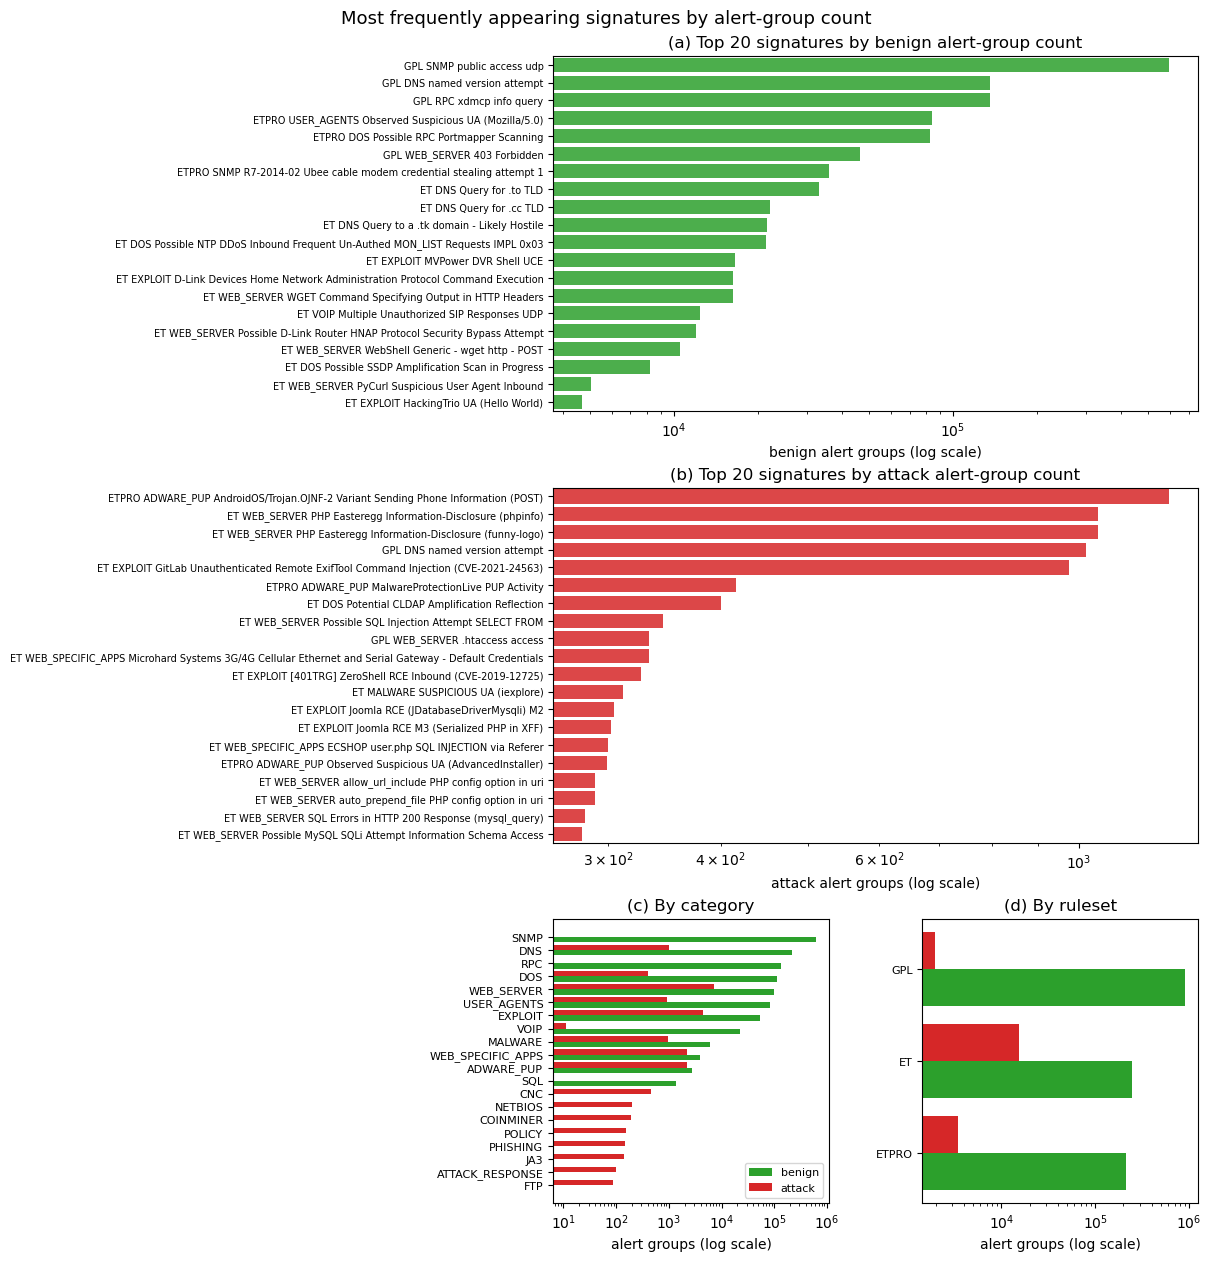

In [ ]:
# Most frequently appearing signatures by alert-group count, as a 2x2 figure:
# (a) top-20 signatures by BENIGN alert-group count, (b) top-20 by ATTACK count,
# (c) by category (EXPLOIT / WEB_SERVER / ...), (d) by ruleset (ET / ETPRO / GPL).
# Each row of the CSCAS CSV is one alert group, so 'count' is a row count, not
# sum(AlertCount). Category / ruleset are the structural prefixes Suricata bakes
# into SignatureText, parsed with the same parse_signature_text the mining
# pipeline uses. CSCAS has no mixed signatures, so (a) and (b) are disjoint sets.
from thesis.preprocessing.suricata_tokenization import parse_signature_text

C_BEN, C_ATT = 'tab:blue', 'tab:red'

sig_meta = df[['SignatureID', 'SignatureText']].drop_duplicates('SignatureID').copy()
sig_meta[['ruleset', 'category', '_desc']] = sig_meta['SignatureText'].apply(
    lambda t: pd.Series(parse_signature_text(t), index=['ruleset', 'category', '_desc'])
)
sig_meta['ruleset'] = sig_meta['ruleset'].replace('', '(none)')
sig_meta['category'] = sig_meta['category'].replace('', '(none)')

d = df[['SignatureID', 'SignatureText', 'Label']].copy()
d['cls'] = np.where(d['Label'] == 1, 'attack', 'benign')
d = d.merge(sig_meta[['SignatureID', 'ruleset', 'category']], on='SignatureID', how='left')

def counts_by(col, top=None):
    t = (d.groupby([col, 'cls']).size().unstack(fill_value=0)
         .reindex(columns=['benign', 'attack'], fill_value=0))
    t['total'] = t['benign'] + t['attack']
    t = t.sort_values('total', ascending=False)
    return (t.head(top) if top else t).iloc[::-1]   # largest ends up on top in barh

TOP_K = 20
sig_ct = (d.groupby(['SignatureText', 'cls']).size().unstack(fill_value=0)
          .reindex(columns=['benign', 'attack'], fill_value=0))
top_ben = sig_ct.sort_values('benign', ascending=False).head(TOP_K).iloc[::-1]
top_att = sig_ct.sort_values('attack', ascending=False).head(TOP_K).iloc[::-1]
by_cat = counts_by('category', top=20)
by_rule = counts_by('ruleset')

# (a) and (b) are stacked full-width so the long SignatureText labels have room;
# (c) and (d) share the bottom row.
fig = plt.figure(figsize=(12, 12.5), constrained_layout=True)
gs = fig.add_gridspec(3, 2, height_ratios=[1.25, 1.25, 1])
axA = fig.add_subplot(gs[0, :])
axB = fig.add_subplot(gs[1, :])
axC = fig.add_subplot(gs[2, 0])
axD = fig.add_subplot(gs[2, 1])

# (a) top signatures by benign count, (b) top signatures by attack count
for ax, tbl, col, color, lbl in [
    (axA, top_ben, 'benign', C_BEN, 'benign'),
    (axB, top_att, 'attack', C_ATT, 'attack'),
]:
    ax.barh(np.arange(len(tbl)), tbl[col], color=color, alpha=0.85)
    ax.set_yticks(np.arange(len(tbl)))
    ax.set_yticklabels(tbl.index, fontsize=7)
    ax.set_ylim(-0.5, len(tbl) - 0.5)
    ax.set_xscale('log')
    ax.set_xlabel(f'{lbl} alert groups (log scale)')
    ax.margins(y=0.01)

axA.set_title(f'(a) Top {TOP_K} signatures by benign alert-group count')
axB.set_title(f'(b) Top {TOP_K} signatures by attack alert-group count')

# (c), (d) grouped benign vs attack bars
for ax, tbl, title in [(axC, by_cat, '(c) By category'), (axD, by_rule, '(d) By ruleset')]:
    y = np.arange(len(tbl))
    ax.barh(y - 0.2, tbl['benign'], height=0.4, color=C_BEN, label='benign')
    ax.barh(y + 0.2, tbl['attack'], height=0.4, color=C_ATT, label='attack')
    ax.set_yticks(y); ax.set_yticklabels(tbl.index, fontsize=8)
    ax.set_xscale('log'); ax.set_xlabel('alert groups (log scale)')
    ax.set_title(title)
axC.legend(fontsize=8, loc='lower right')

fig.suptitle('Most frequently appearing signatures by alert-group count', fontsize=13)
plt.show()


## 7. Similarity Feature Overview

**Appendix figure:** all 34 per-attribute similarity features plus the aggregate
`Similarity`, benign vs attack. For each feature: the `-1` sentinel (attribute not
present in the alert group) is dropped, the remaining values are histogrammed by
class, and a separability AUC is computed from the raw feature value used as a
1-D score (0.5 = no separation, 1.0 = perfect). This shows whether CSCAS's own
similarity features are near-perfect discriminators -- and how much that depends
on each feature actually being populated (coverage is typically single-digit %).

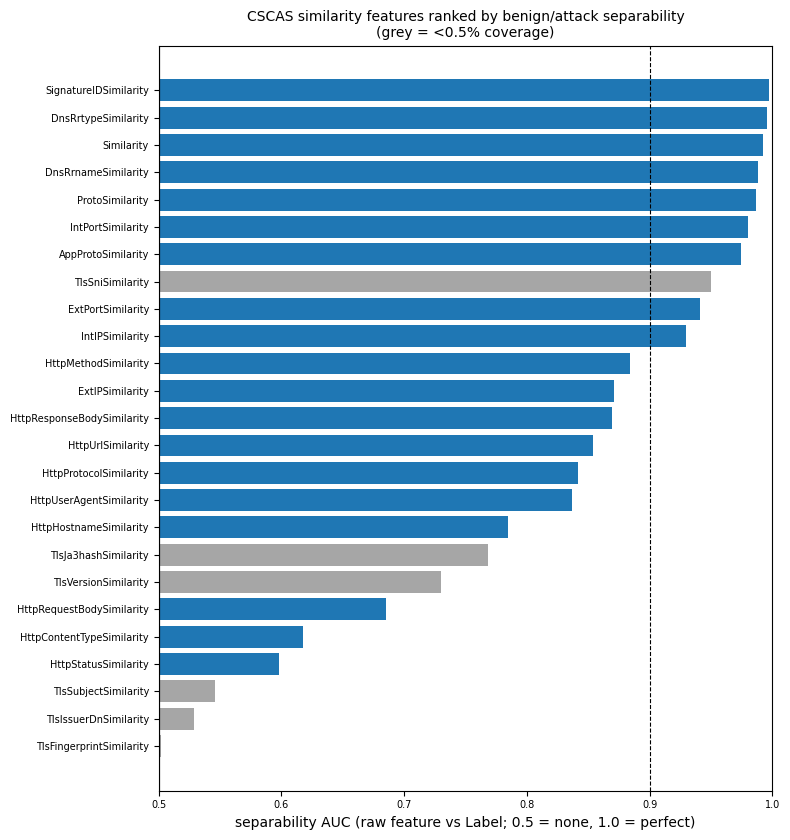

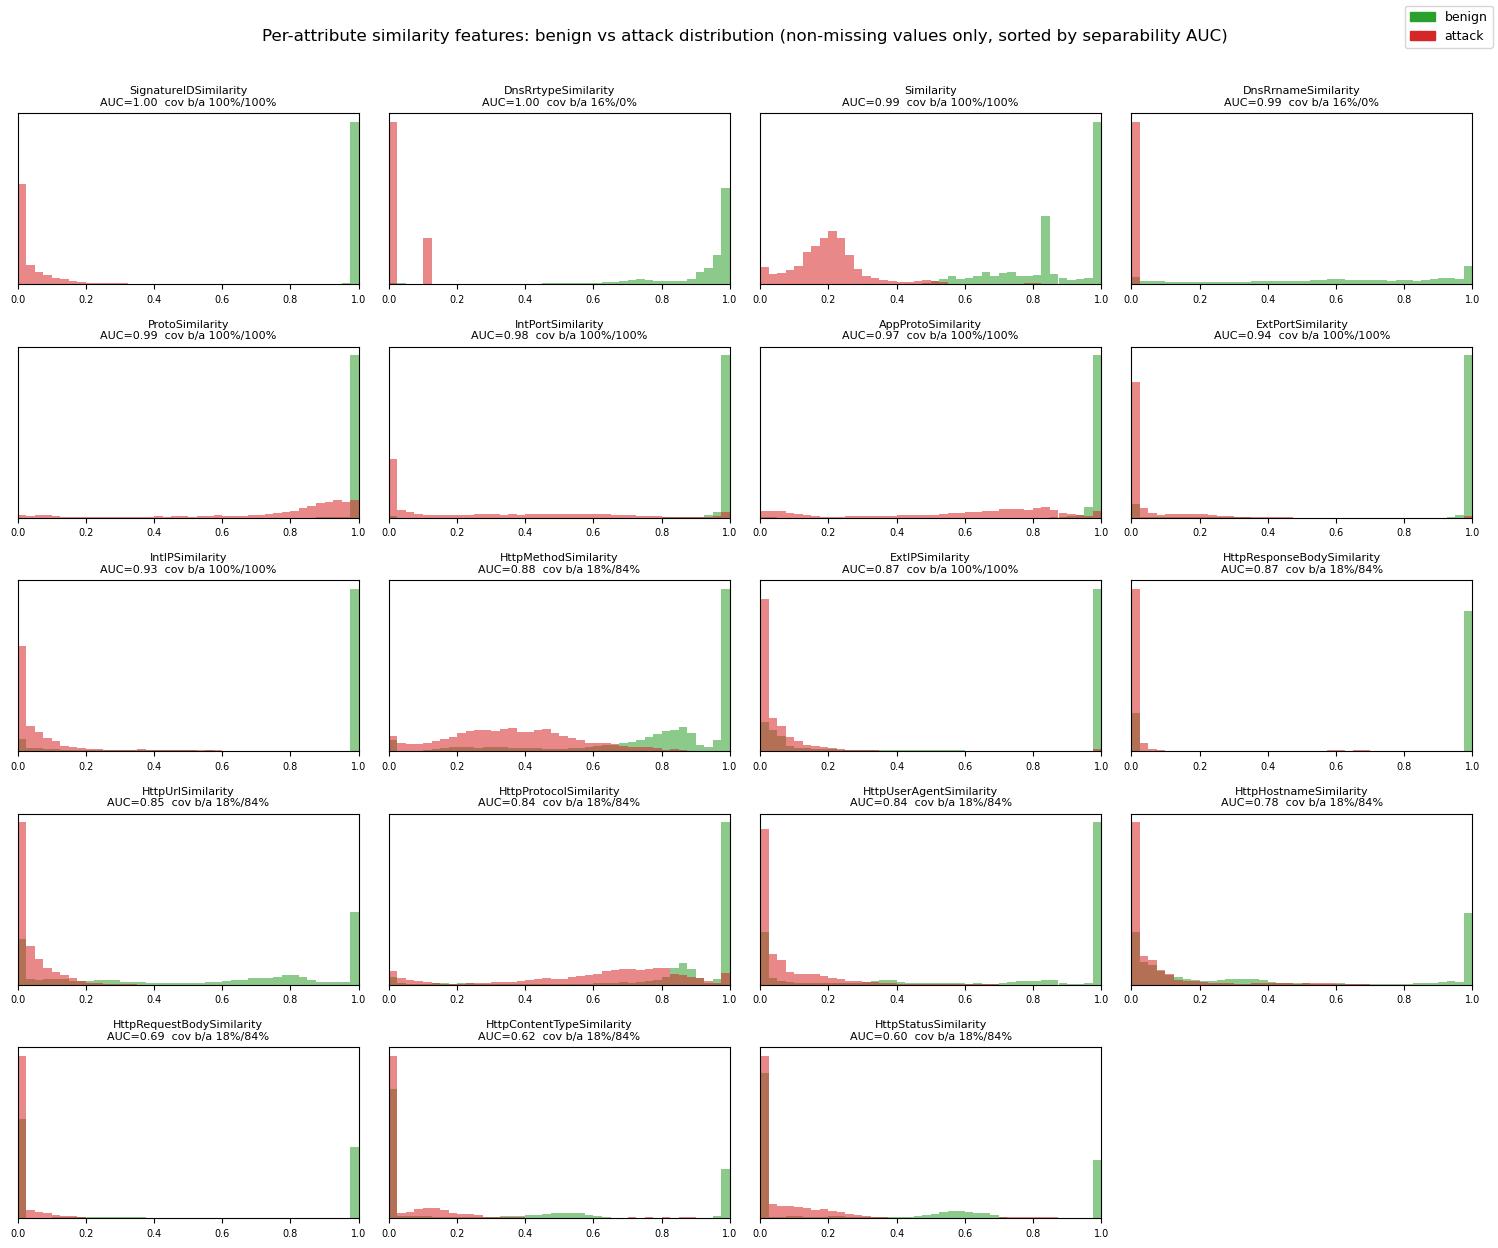

19/35 similarity features have >= 0.5% coverage.
among those: median separability AUC = 0.88, 9 >= 0.90, 7 >= 0.95
aggregate `Similarity`: AUC = 0.99, coverage = 100%


,feature,coverage,cov_benign,cov_attack,auc
0,SignatureIDSimilarity,1.000,1.000,1.000,0.997
1,DnsRrtypeSimilarity,0.161,0.164,0.000,0.995
2,Similarity,1.000,1.000,1.000,0.992
3,DnsRrnameSimilarity,0.161,0.164,0.000,0.988
4,ProtoSimilarity,1.000,1.000,1.000,0.987
5,IntPortSimilarity,1.000,1.000,1.000,0.980
6,AppProtoSimilarity,1.000,1.000,1.000,0.974
7,TlsSniSimilarity,0.001,0.001,0.033,0.950
8,ExtPortSimilarity,1.000,1.000,1.000,0.941
9,IntIPSimilarity,1.000,1.000,1.000,0.930


In [ ]:
from sklearn.metrics import roc_auc_score
import matplotlib.patches as mpatches

sim_feats = ['Similarity'] + sorted(
    c for c in df.columns if c.endswith('Similarity') and c != 'Similarity'
)
y = df['Label']
n_ben, n_att = (y == 0).sum(), (y == 1).sum()

def sep_auc(x):
    m = x.notna() & (x != -1)
    if m.sum() < 2 or y[m].nunique() < 2:
        return np.nan
    a = roc_auc_score(y[m], x[m])
    return max(a, 1 - a)

rows = []
for c in sim_feats:
    valid = df[c].notna() & (df[c] != -1)
    rows.append({
        'feature': c,
        'coverage': valid.mean(),
        'cov_benign': (valid & (y == 0)).sum() / n_ben,
        'cov_attack': (valid & (y == 1)).sum() / n_att,
        'auc': sep_auc(df[c]),
    })
sim_summary = (pd.DataFrame(rows)
               .sort_values('auc', ascending=False, na_position='last')
               .reset_index(drop=True))

MIN_COV = 0.005
plotted = sim_summary[sim_summary['coverage'] >= MIN_COV].reset_index(drop=True)

# --- headline: every feature ranked by separability AUC ---
s = sim_summary.dropna(subset=['auc']).sort_values('auc')
fig0, ax0 = plt.subplots(figsize=(8, 0.30 * len(s) + 1))
ax0.barh(s['feature'], s['auc'],
         color=['0.65' if cov < MIN_COV else 'tab:blue' for cov in s['coverage']])
ax0.axvline(0.5, color='k', lw=0.8)
ax0.axvline(0.9, color='k', ls='--', lw=0.8)
ax0.set_xlim(0.5, 1.0)
ax0.set_xlabel('separability AUC (raw feature vs Label; 0.5 = none, 1.0 = perfect)')
ax0.set_title('CSCAS similarity features ranked by benign/attack separability\n'
              '(grey = <0.5% coverage)', fontsize=10)
ax0.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

# --- detail: per-feature distributions, benign vs attack ---
ncol = 4
nrow = int(np.ceil(len(plotted) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5 * nrow), squeeze=False)
bins = np.linspace(0, 1, 41)
for i, r in plotted.iterrows():
    ax = axes[i // ncol][i % ncol]
    for lab, color in [(0, 'tab:blue'), (1, 'tab:red')]:
        v = df.loc[(y == lab) & (df[r['feature']] != -1) & df[r['feature']].notna(), r['feature']]
        if len(v):
            ax.hist(v, bins=bins, density=True, alpha=0.55, color=color)
    ax.set_title(f"{r['feature']}\nAUC={r['auc']:.2f}  cov b/a {r['cov_benign']:.0%}/{r['cov_attack']:.0%}",
                 fontsize=8)
    ax.set_xlim(0, 1); ax.set_yticks([]); ax.tick_params(labelsize=7)
for j in range(len(plotted), nrow * ncol):
    axes[j // ncol][j % ncol].set_visible(False)
fig.legend(handles=[mpatches.Patch(color='tab:blue', label='benign'),
                    mpatches.Patch(color='tab:red', label='attack')],
           loc='upper right', fontsize=9)
fig.suptitle('Per-attribute similarity features: benign vs attack distribution '
             '(non-missing values only, sorted by separability AUC)', fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

cov = plotted
print(f'{len(plotted)}/{len(sim_summary)} similarity features have >= {MIN_COV:.1%} coverage.')
print(f'among those: median separability AUC = {cov.auc.median():.2f}, '
      f'{(cov.auc >= 0.9).sum()} >= 0.90, {(cov.auc >= 0.95).sum()} >= 0.95')
print(f'aggregate `Similarity`: AUC = {sim_summary.set_index("feature").loc["Similarity", "auc"]:.2f}, '
      f'coverage = {sim_summary.set_index("feature").loc["Similarity", "coverage"]:.0%}')
display(sim_summary.round(3))


## 15. Dataset-level EDA (run_eda / run_eda_host parity)

Reproduces the analysis + plots from the old `run_eda.py` script for the `cscas` dataset (a single pre-grouped scenario, also named `cscas`), via `thesis.data.eda` (computation) and `thesis.visualization.eda` (plotting). No per-host section here -- cscas rows have no `host` column, that analysis is AIT-ADS only. Output is written under `artifacts/experiments/run_eda/cscas/`, same layout the script used.

In [ ]:
import sys
from datetime import datetime, timezone
from pathlib import Path

REPO2 = Path.cwd().resolve().parents[3]
sys.path.insert(0, str(REPO2 / 'src'))

import thesis.data.eda as de
from thesis.configs import load_scenarios
from thesis.visualization.eda import load_alerts, plot_label_distribution_table

DATASET2 = 'cscas'
DATA_DIR2 = REPO2 / 'data' / 'cscas'
scenarios2 = load_scenarios(DATASET2)
print(f'Scenarios: {scenarios2}')

run_ts2 = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
run_dir2 = REPO2 / 'artifacts' / 'experiments' / 'run_eda' / DATASET2 / f'run_{run_ts2}_raw'
summary_dir2 = run_dir2 / 'summary'
print(f'Output dir: {run_dir2}')

Scenarios: ['cscas']
Output dir: /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/cscas/run_20260902_211307_raw


### Load alerts

In [ ]:
all_df2 = load_alerts(str(DATA_DIR2), scenarios=scenarios2, dataset=DATASET2)
print(f'{len(all_df2):,} alerts loaded.')
all_df2.head()

1,395,324 alerts loaded.


,Timestamp,SignatureText,SignatureID,SignatureMatchesPerDay,AlertCount,Proto,ExtIP,ExtPort,IntIP,IntPort,Similarity,Label,SCAS,AppProtoSimilarity,DnsRrnameSimilarity,DnsRrtypeSimilarity,EmailFromSimilarity,EmailStatusSimilarity,EmailToSimilarity,ExtIPSimilarity,ExtPortSimilarity,HttpContentTypeSimilarity,HttpHostnameSimilarity,HttpMethodSimilarity,HttpProtocolSimilarity,HttpRequestBodySimilarity,HttpResponseBodySimilarity,HttpStatusSimilarity,HttpUrlSimilarity,HttpUserAgentSimilarity,IntIPSimilarity,IntPortSimilarity,ProtoSimilarity,SignatureIDSimilarity,SmtpHeloSimilarity,SmtpMailFromSimilarity,SmtpRcptToSimilarity,SshClientProtoSimilarity,SshClientSoftwareSimilarity,SshServerProtoSimilarity,SshServerSoftwareSimilarity,TlsFingerprintSimilarity,TlsIssuerDnSimilarity,TlsJa3hashSimilarity,TlsSniSimilarity,TlsSubjectSimilarity,TlsVersionSimilarity,timestamp,time,scenario,is_attack,label,signature,ip
0,2022-01-20T00:00:03+02:00,GPL SNMP public access udp,2101411,140201.481767,4,17,extip1,57239,-1,161,0.998231,0,0,0.989388,-1.0,-1.0,-1,-1,-1,1.000000,1.00000,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,1.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:03+00:00,1642629603,cscas,False,false_positive,GPL SNMP public access udp,extip1
1,2022-01-20T00:00:13+02:00,GPL SNMP public access udp,2101411,140201.525122,1,17,extip2,32050,intip1,161,0.998249,0,0,0.989494,-1.0,-1.0,-1,-1,-1,1.000000,1.00000,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,1.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:13+00:00,1642629613,cscas,False,false_positive,GPL SNMP public access udp,extip2
2,2022-01-20T00:00:17+02:00,ET VOIP REGISTER Message Flood UDP,2009699,298.864011,1,17,extip3,9999,intip2,5060,0.505563,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.016690,0.01669,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,0.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:17+00:00,1642629617,cscas,False,false_positive,ET VOIP REGISTER Message Flood UDP,extip3
3,2022-01-20T00:00:31+02:00,ET EXPLOIT D-Link Devices Home Network Administration Pr...,2020899,841.202279,1,6,extip4,44774,intip3,80,0.725752,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.524855,1.00000,0.0,1.0,1.0,0.782562,0.0,1.0,0.0,0.900447,0.683009,1.0,0.995414,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:31+00:00,1642629631,cscas,False,false_positive,ET EXPLOIT D-Link Devices Home Network Administration Pr...,extip4
4,2022-01-20T00:00:31+02:00,ET WEB_SERVER WGET Command Specifying Output in HTTP Hea...,2019309,841.311867,1,6,extip4,44774,intip3,80,0.725752,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.524855,1.00000,0.0,1.0,1.0,0.782560,0.0,1.0,0.0,0.900447,0.683007,1.0,0.995414,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:31+00:00,1642629631,cscas,False,false_positive,ET WEB_SERVER WGET Command Specifying Output in HTTP Hea...,extip4


### Phase 1: per-scenario analysis

cscas is pre-grouped (one row per already-aggregated basket, not a raw alert-by-alert stream), so alert_group construction doesn't apply here -- this just writes the per-scenario text summary (basic stats, missing values, label distribution, top signatures).

In [ ]:
for scenario in scenarios2:
    scenario_df2 = all_df2[all_df2['scenario'] == scenario].copy()
    de.run_scenario_eda(
        scenario_df2,
        scenario,
        out_path=run_dir2 / scenario,
        summary_path=summary_dir2,
    )
    del scenario_df2

  Running EDA for scenario 'cscas' (n=1,395,324 rows)...
  cscas: done → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/cscas/run_20260902_211307_raw/cscas


### Cross-scenario tables

cscas has a single scenario, so these tables have one row -- still useful as the same standardized summary the AIT-ADS notebook produces.

In [ ]:
overview_df2 = de.compute_overview_table(all_df2)
overview_df2.to_csv(run_dir2 / 'overview_table.csv', index=False)
overview_df2

,scenario,start,end,duration_days,total_alerts,benign_alerts,attack_alerts,attack_pct,unique_signatures,attack_types
0,cscas,2022-01-19,2022-03-20,60.0,1395324,1374372,20952,1.5,585,1


In [ ]:
label_dist_df2 = de.compute_label_distribution_table(all_df2)
label_dist_df2.to_csv(run_dir2 / 'label_distribution_table.csv', index=False)

### Phase 2: overview plots

cscas-specific plots (temporal attack overview, signature event raster) plus the shared attack-type heatmap.

In [ ]:
plots2 = de.build_overview_plots(scenarios2, all_df2, dataset=DATASET2)
de.save_overview_plots(plots2, run_dir2 / 'plots', de.data_label(), close=True)

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/visualization/eda.py:1275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0, 1, 0.97))



[plots] Saving to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/cscas/run_20260902_211307_raw/plots
  Saving temporal attack overview... done
  Saving signature event raster... done
  Saving signature_burst_raster... done
  Saving signature purity pie... done
  Saving class balance... done
  Saving attack type heatmap... done
  Saving top alert signatures... done
  Saving inter-arrival time CDF... done
  Saving group size distribution... done
  Saving scenario overview table... done


### Temporal concentration of attacks

The 1h-bin overview above cannot resolve campaign structure. The next cell asks,
three ways, whether attack groups cluster in time: (a) cumulative attack groups vs
elapsed time against the uniform diagonal; (b) what share of attack groups falls in
the busiest slices of the timeline; (c) the distribution of gaps between consecutive
attack groups (any signature) against the same distribution for consecutive
groups of a single signature, and against an exponential of the same mean. If the
pooled curve clusters at short gaps but the per-signature curve does not, the
clustering is different signatures co-firing, not any one signature repeating.

The cell after that segments the attack stream at a few gap thresholds and checks
whether it breaks into a handful of dense campaigns or stays a diffuse trickle
(same primitive as time-delta grouping, at campaign timescale).

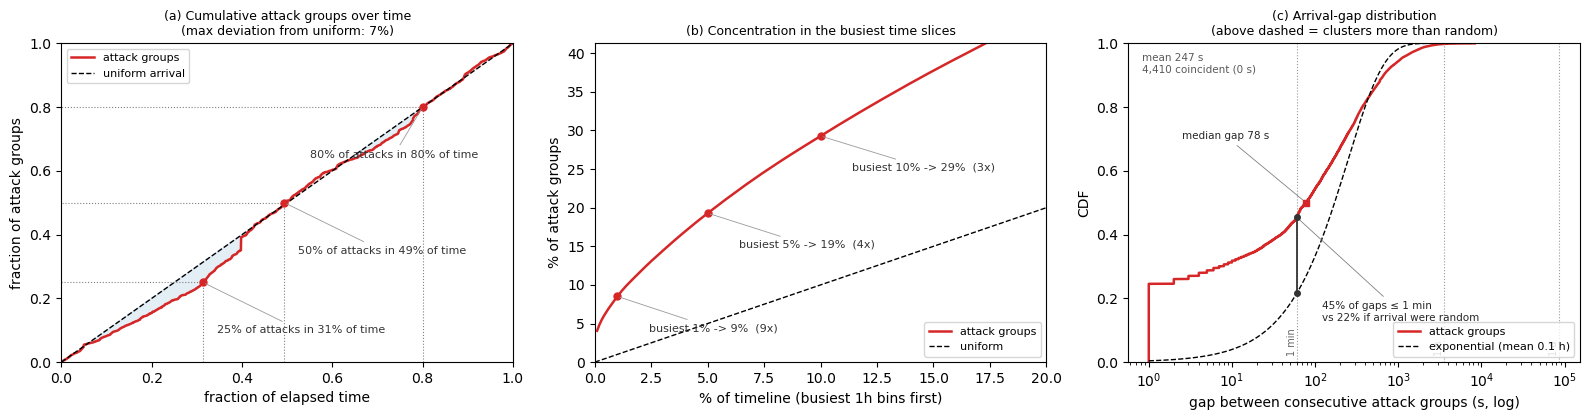

Temporal concentration of attack groups (uniform arrival = diagonal):
  first 25% of attack groups fall within 31.4% of the timeline
  first 50% of attack groups fall within 49.4% of the timeline
  first 80% of attack groups fall within 80.0% of the timeline
  busiest 1% of time holds 8.5% of attack groups (8.5x over-representation)
  busiest 5% of time holds 19.3% of attack groups (3.9x over-representation)
  busiest 10% of time holds 29.3% of attack groups (2.9x over-representation)

Arrival gaps: median 78 s, mean 247 s, 4,410 coincident (0 s); 45% of gaps <= 1 min vs 22% expected under exponential arrival


In [ ]:
# Temporal concentration of attack groups, three views:
#   (a) cumulative attack groups vs elapsed time, against the uniform diagonal
#   (b) share of attack groups in the busiest slices of the timeline
#   (c) gap between consecutive attack groups vs an exponential of the same mean
#       (what a memoryless / no-clustering arrival process would give)
# Printed facts are drawn straight onto the panels.
att = all_df2.loc[all_df2.is_attack].sort_values('time').reset_index(drop=True)
t0, t1 = att.time.min(), all_df2.time.max()
frac_time = (att.time.values - t0) / (t1 - t0)
frac_att = np.arange(1, len(att) + 1) / len(att)

edges = np.linspace(0, 1, 1001)
binned = np.histogram(frac_time, bins=edges)[0]
busiest = np.sort(binned)[::-1].cumsum() / binned.sum()

def _time_for(pp):
    return float(frac_time[min(np.searchsorted(frac_att, pp), len(att) - 1)])
q_facts = [(pp, _time_for(pp)) for pp in (0.25, 0.5, 0.8)]
b_facts = [(q, float(busiest[int(q * 1000) - 1])) for q in (0.01, 0.05, 0.10)]
max_dev = float(np.max(np.abs(frac_att - frac_time)))

fig, (axL, axR, axG) = plt.subplots(1, 3, figsize=(16, 4.3))

# (a) cumulative curve vs uniform arrival (diagonal)
axL.fill_between(frac_time, frac_time, frac_att, where=frac_att >= frac_time,
                 color='tab:red', alpha=0.12)
axL.fill_between(frac_time, frac_time, frac_att, where=frac_att < frac_time,
                 color='tab:blue', alpha=0.12)
axL.plot(frac_time, frac_att, lw=1.8, color='tab:red', label='attack groups')
axL.plot([0, 1], [0, 1], 'k--', lw=1, label='uniform arrival')
for pp, tf in q_facts:
    axL.plot([tf, tf, 0], [0, pp, pp], color='0.5', lw=0.8, ls=':')
    axL.plot(tf, pp, 'o', color='tab:red', ms=5)
    axL.annotate(f'{pp:.0%} of attacks in {tf:.0%} of time', xy=(tf, pp),
                 xytext=(min(tf + 0.03, 0.55), max(pp - 0.16, 0.03)), fontsize=8,
                 color='0.2', arrowprops=dict(arrowstyle='-', color='0.6', lw=0.6))
axL.set_xlim(0, 1); axL.set_ylim(0, 1)
axL.set_xlabel('fraction of elapsed time'); axL.set_ylabel('fraction of attack groups')
axL.set_title(f'(a) Cumulative attack groups over time\n(max deviation from uniform: {max_dev:.0%})',
              fontsize=9)
axL.legend(loc='upper left', fontsize=8)

# (b) busiest x% of the timeline
axR.plot(edges[1:] * 100, busiest * 100, lw=1.8, color='tab:red', label='attack groups')
axR.plot([0, 100], [0, 100], 'k--', lw=1, label='uniform')
for q, sh in b_facts:
    axR.plot(q * 100, sh * 100, 'o', color='tab:red', ms=5)
    axR.annotate(f'busiest {q:.0%} -> {sh:.0%}  ({sh / q:.0f}x)', xy=(q * 100, sh * 100),
                 xytext=(q * 100 + 1.4, sh * 100 - 4.5), fontsize=8, color='0.2',
                 arrowprops=dict(arrowstyle='-', color='0.6', lw=0.6))
axR.set_xlim(0, 20); axR.set_ylim(0, max(40, b_facts[-1][1] * 100 + 12))
axR.set_xlabel('% of timeline (busiest 1h bins first)'); axR.set_ylabel('% of attack groups')
axR.set_title('(b) Concentration in the busiest time slices', fontsize=9)
axR.legend(loc='lower right', fontsize=8)

# (c) arrival-gap CDF: gaps between consecutive attack groups (any signature) vs
#     gaps between consecutive groups of the SAME signature. The pooled curve
#     clusters far more at short gaps than the per-signature one, so the
#     sub-minute clustering is different signatures firing together, not any one
#     signature repeating.
gap = np.diff(att.time.values.astype(float))          # sorted, so all >= 0
n_zero = int((gap == 0).sum())
gs = np.sort(gap)
mean_gap = gap.mean()

_gsig = [np.diff(np.sort(t.values.astype(float)))
         for _, t in att.groupby('signature')['time'] if len(t) > 1]
gsig = np.sort(np.concatenate(_gsig)) if _gsig else np.array([1.0])

def _cdf(a):
    return np.clip(a, 1, None), np.arange(1, len(a) + 1) / len(a)

x_all, y_all = _cdf(gs)
x_sig, y_sig = _cdf(gsig)
grid = np.logspace(0, np.log10(gs.max() + 1), 200)
axG.plot(x_all, y_all, lw=1.8, color='tab:red', label='any signature')
axG.plot(x_sig, y_sig, lw=1.8, color='tab:orange', label='same signature')
axG.plot(grid, 1 - np.exp(-grid / mean_gap), 'k--', lw=1, label='exponential')
for sec, lbl in [(60, '1 min'), (3600, '1 h'), (86400, '1 d')]:
    axG.axvline(sec, ls=':', color='0.6', lw=0.8)
    axG.text(sec, 0.02, lbl, rotation=90, fontsize=7, va='bottom', ha='right', color='0.4')

m_all, m_sig = float(np.median(gs)), float(np.median(gsig))
f_all, f_sig = (gs <= 60).mean(), (gsig <= 60).mean()
axG.text(0.03, 0.97,
         f'gaps \u2264 1 min:  any sig {f_all:.0%},  same sig {f_sig:.0%}\n'
         f'median gap:   any sig {m_all:,.0f} s,  same sig {m_sig:,.0f} s\n'
         f'{n_zero:,} coincident (0 s)',
         transform=axG.transAxes, fontsize=6.5, va='top', color='0.3', family='monospace')

axG.set_xscale('log'); axG.set_ylim(0, 1)
axG.set_xlabel('gap between consecutive attack groups (s, log)')
axG.set_ylabel('CDF')
axG.set_title('(c) Arrival-gap distribution\n(pooled clusters more than any one signature)',
              fontsize=9)
axG.legend(loc='lower right', fontsize=7.5)

plt.tight_layout(); plt.show()

print('Temporal concentration of attack groups (uniform arrival = diagonal):')
for pp, tf in q_facts:
    print(f'  first {pp:.0%} of attack groups fall within {tf:.1%} of the timeline')
for q, sh in b_facts:
    print(f'  busiest {q:.0%} of time holds {sh:.1%} of attack groups ({sh / q:.1f}x over-representation)')
print(f'\nArrival gaps between consecutive attack groups:')
print(f'  any signature : median {m_all:,.0f} s, {f_all:.0%} <= 1 min, {n_zero:,} coincident '
      f'(vs {1 - np.exp(-60 / mean_gap):.0%} <= 1 min under exponential arrival)')
print(f'  same signature: median {m_sig:,.0f} s, {f_sig:.0%} <= 1 min')


### Attack-signature activity raster

Ties "campaign" to *which* signatures fire, not just volume. Rendered as a 2D histogram (time bin x signature, log colour), signatures ordered by first appearance. A campaign shows as a vertical stripe spanning many signature rows; a diffuse trickle shows as scattered cells. The lower edge of the coloured region is the "first-seen staircase" -- a steep step means a burst of previously-unseen signatures entering at once. Benign signatures shown alongside as the stable-background contrast.

`plot_occurrence_burst_raster` (marker version, count-ordered, with per-signature labels) is still written to `plots/signature_burst_raster.png` by `build_overview_plots` above if the row-level detail is needed.

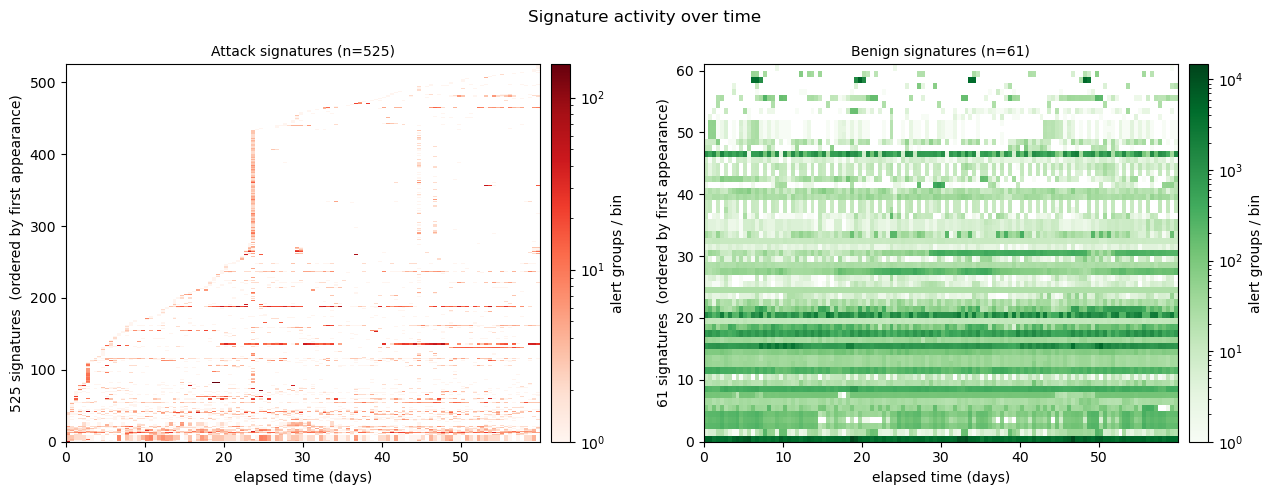

In [ ]:
import matplotlib.colors as mcolors

# Compact time x signature activity heatmap. Signatures ordered by first
# appearance; cell colour = number of alert groups for that signature in that
# time bin (log). Campaign = vertical stripe across many rows.
def sig_activity_heatmap(sub, ax, title, cmap, n_tbins=120):
    g0 = all_df2.time.min()
    span_days = (all_df2.time.max() - g0) / 86400
    order = sub.groupby('signature').time.min().sort_values().index
    row = {s: i for i, s in enumerate(order)}
    x = (sub.time.values - g0) / 86400
    y = sub.signature.map(row).values
    H, xe, ye = np.histogram2d(
        x, y, bins=[n_tbins, len(order)],
        range=[[0, span_days], [0, len(order)]],
    )
    pcm = ax.pcolormesh(xe, ye, H.T, cmap=cmap, rasterized=True,
                        norm=mcolors.LogNorm(vmin=1, vmax=H.max()))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('elapsed time (days)')
    ax.set_ylabel(f'{len(order)} signatures  (ordered by first appearance)')
    ax.set_ylim(0, len(order))
    fig.colorbar(pcm, ax=ax, pad=0.02, label='alert groups / bin')

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
sig_activity_heatmap(all_df2[all_df2.is_attack], axA,
                     f'Attack signatures (n={all_df2.loc[all_df2.is_attack, "signature"].nunique()})',
                     'Reds')
sig_activity_heatmap(all_df2[~all_df2.is_attack], axB,
                     f'Benign signatures (n={all_df2.loc[~all_df2.is_attack, "signature"].nunique()})',
                     'Blues')
fig.suptitle('Signature activity over time', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Free the section-15 copies before section 16 reloads df from scratch --
# all_df2/plots2 are full-size duplicates of the CSV and otherwise sit in
# memory unused for the rest of the run.
import gc

del all_df2, plots2
gc.collect()

201718

## 16. Field/Feature Overview — Summary CSVs

Tabular numerical overview of the raw dataset's fields, written to `overview_csvs/` next to this notebook: signature behavior (always-benign / always-attack / mixed, CVE coverage, per-day and per-hour activity), and network fields (IP/port/protocol cardinality and the `-1` "multiple values aggregated into this row" sentinel). Reloads `df` fresh from `DATA_PATH` so it's independent of whatever the preceding sections left `df` as.

In [ ]:
from pathlib import Path

df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])

OVERVIEW_DIR = Path('overview_csvs')
OVERVIEW_DIR.mkdir(exist_ok=True)
print(f'Writing overview CSVs to {OVERVIEW_DIR.resolve()}')
print(f'{len(df):,} rows')

### 16.1 Signature analysis

Per-signature stats (count, benign/attack split, always-benign / always-attack / mixed classification, days/hours active, CVE refs), plus dataset-level rollups.

In [ ]:
sig_stats = df.groupby(['SignatureID', 'SignatureText']).agg(
    count=('Label', 'count'),
    attack_count=('Label', 'sum'),
).reset_index()
sig_stats['benign_count'] = sig_stats['count'] - sig_stats['attack_count']
sig_stats['attack_rate%'] = (sig_stats['attack_count'] / sig_stats['count'] * 100).round(3)
sig_stats['sig_class'] = np.select(
    [sig_stats['attack_count'] == 0, sig_stats['benign_count'] == 0],
    ['always_benign', 'always_attack'],
    default='mixed',
)

span = df.groupby('SignatureID').agg(
    n_days_active=('Timestamp', lambda s: s.dt.normalize().nunique()),
    n_hours_active=('Timestamp', lambda s: s.dt.floor('h').nunique()),
    first_seen=('Timestamp', 'min'),
    last_seen=('Timestamp', 'max'),
).reset_index()
sig_stats = sig_stats.merge(span, on='SignatureID')

# Attach CVE refs / category from the tokenization output (section 10), if it has been run.
try:
    tok = pd.read_csv('tokenized_signatures2.csv')
    sig_stats = sig_stats.merge(
        tok[['signature_id', 'cve_refs', 'category']].rename(columns={'signature_id': 'SignatureID'}),
        on='SignatureID', how='left',
    )
except FileNotFoundError:
    sig_stats['cve_refs'] = None
    sig_stats['category'] = None

sig_stats = sig_stats.sort_values('count', ascending=False)
sig_stats.to_csv(OVERVIEW_DIR / 'signature_overview.csv', index=False)
print(f'{len(sig_stats)} signatures -> signature_overview.csv')
sig_stats.head()

587 signatures -> signature_overview.csv


,SignatureID,SignatureText,count,attack_count,benign_count,attack_rate%,sig_class,n_days_active,n_hours_active,first_seen,last_seen,cve_refs,category
459,2101411,GPL SNMP public access udp,592445,0,592445,0.0,always_benign,60,1440,2022-01-20 00:00:03+02:00,2022-03-20 23:59:58+02:00,None,None
461,2101616,GPL DNS named version attempt,135622,0,135622,0.0,always_benign,60,1440,2022-01-20 00:02:02+02:00,2022-03-20 23:56:53+02:00,None,None
462,2101867,GPL RPC xdmcp info query,135350,0,135350,0.0,always_benign,60,1440,2022-01-20 00:11:31+02:00,2022-03-20 23:58:33+02:00,None,None
558,2842116,ETPRO USER_AGENTS Observed Suspicious UA (Mozilla/5.0),84112,0,84112,0.0,always_benign,60,1440,2022-01-20 00:03:11+02:00,2022-03-20 23:59:55+02:00,None,None
512,2812543,ETPRO DOS Possible RPC Portmapper Scanning,82503,0,82503,0.0,always_benign,60,987,2022-01-20 05:33:44+02:00,2022-03-20 23:28:45+02:00,None,None


In [ ]:
all_cves = set()
if sig_stats['cve_refs'].notna().any():
    for refs in sig_stats['cve_refs'].dropna():
        if refs:
            all_cves.update(refs.split('|'))

signature_summary = pd.DataFrame([{
    'n_unique_signatures': sig_stats['SignatureID'].nunique(),
    'n_always_benign_signatures': int((sig_stats['sig_class'] == 'always_benign').sum()),
    'n_always_attack_signatures': int((sig_stats['sig_class'] == 'always_attack').sum()),
    'n_mixed_signatures': int((sig_stats['sig_class'] == 'mixed').sum()),
    'n_unique_cves': len(all_cves),
}])
signature_summary.to_csv(OVERVIEW_DIR / 'signature_summary.csv', index=False)
signature_summary

,n_unique_signatures,n_always_benign_signatures,n_always_attack_signatures,n_mixed_signatures,n_unique_cves
0,587,61,526,0,0


### 16.2 Signature activity per day / per hour

For each calendar-day and each hourly bin: how many distinct signatures were active, split by their global class (`always_benign` / `always_attack` / `mixed`), and what fraction of that bin's active signatures each class represents. `signature_activity_summary.csv` collapses each series to min/max/mean.

In [ ]:
sig_class_map = sig_stats.set_index('SignatureID')['sig_class']
df['_sig_overview_class'] = df['SignatureID'].map(sig_class_map)


def signature_activity_by_bin(freq):
    binned = df[['Timestamp', 'SignatureID', '_sig_overview_class']].copy()
    binned['bin'] = binned['Timestamp'].dt.floor(freq)
    active = binned.groupby(['bin', 'SignatureID'])['_sig_overview_class'].first().reset_index()
    counts = (
        active.groupby(['bin', '_sig_overview_class'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=['always_benign', 'always_attack', 'mixed'], fill_value=0)
    )
    counts['n_active_signatures'] = counts.sum(axis=1)
    counts['frac_benign'] = counts['always_benign'] / counts['n_active_signatures']
    counts['frac_attack'] = counts['always_attack'] / counts['n_active_signatures']
    counts['frac_mixed'] = counts['mixed'] / counts['n_active_signatures']
    return counts.reset_index().rename(columns={'bin': 'Timestamp'})


daily_sig_activity = signature_activity_by_bin('D')
hourly_sig_activity = signature_activity_by_bin('h')

daily_sig_activity.to_csv(OVERVIEW_DIR / 'signature_activity_per_day.csv', index=False)
hourly_sig_activity.to_csv(OVERVIEW_DIR / 'signature_activity_per_hour.csv', index=False)

print(f'{len(daily_sig_activity)} daily bins -> signature_activity_per_day.csv')
print(f'{len(hourly_sig_activity)} hourly bins -> signature_activity_per_hour.csv')
daily_sig_activity.head()

60 daily bins -> signature_activity_per_day.csv
1440 hourly bins -> signature_activity_per_hour.csv


_sig_overview_class,Timestamp,always_benign,always_attack,mixed,n_active_signatures,frac_benign,frac_attack,frac_mixed
0,2022-01-20 00:00:00+02:00,53,55,0,108,0.490741,0.509259,0.0
1,2022-01-21 00:00:00+02:00,55,55,0,110,0.500000,0.500000,0.0
2,2022-01-22 00:00:00+02:00,53,77,0,130,0.407692,0.592308,0.0
3,2022-01-23 00:00:00+02:00,53,40,0,93,0.569892,0.430108,0.0
4,2022-01-24 00:00:00+02:00,53,67,0,120,0.441667,0.558333,0.0


In [ ]:
def summarize_activity(counts_df, granularity):
    cols = ['always_benign', 'always_attack', 'mixed', 'n_active_signatures',
            'frac_benign', 'frac_attack', 'frac_mixed']
    return [
        {
            'granularity': granularity,
            'metric': col,
            'min': counts_df[col].min(),
            'max': counts_df[col].max(),
            'mean': counts_df[col].mean(),
        }
        for col in cols
    ]


signature_activity_summary = pd.DataFrame(
    summarize_activity(daily_sig_activity, 'day') + summarize_activity(hourly_sig_activity, 'hour')
)
signature_activity_summary[['min', 'max', 'mean']] = signature_activity_summary[['min', 'max', 'mean']].round(4)
signature_activity_summary.to_csv(OVERVIEW_DIR / 'signature_activity_summary.csv', index=False)
signature_activity_summary

,granularity,metric,min,max,mean
0,day,always_benign,48.0000,57.0000,52.7667
1,day,always_attack,39.0000,257.0000,69.8333
2,day,mixed,0.0000,0.0000,0.0000
3,day,n_active_signatures,88.0000,309.0000,122.6000
4,day,frac_benign,0.1683,0.5699,0.4439
5,day,frac_attack,0.4301,0.8317,0.5561
6,day,frac_mixed,0.0000,0.0000,0.0000
7,hour,always_benign,21.0000,43.0000,31.7778
8,hour,always_attack,0.0000,200.0000,8.1465
9,hour,mixed,0.0000,0.0000,0.0000


### 16.3 Network fields — IP / port / protocol

Cardinality of `IntIP`, `ExtIP`, `Proto`, `IntPort`, `ExtPort`, plus how often each field's `-1` sentinel appears (meaning: the underlying session/basket touched *multiple* distinct values for that field, not resolvable to one).

In [ ]:
def multi_row_stats(series, sentinel):
    is_multi = series == sentinel
    return int(is_multi.sum()), round(float(is_multi.mean()) * 100, 3)


n_multi_int_ip, pct_multi_int_ip = multi_row_stats(df['IntIP'], '-1')
n_multi_ext_ip, pct_multi_ext_ip = multi_row_stats(df['ExtIP'], '-1')
n_multi_proto, pct_multi_proto = multi_row_stats(df['Proto'], -1)
n_multi_int_port, pct_multi_int_port = multi_row_stats(df['IntPort'], -1)
n_multi_ext_port, pct_multi_ext_port = multi_row_stats(df['ExtPort'], -1)

network_overview = pd.DataFrame([{
    'total_rows': len(df),
    'n_distinct_int_ip': df.loc[df['IntIP'] != '-1', 'IntIP'].nunique(),
    'n_rows_multi_int_ip': n_multi_int_ip,
    'pct_rows_multi_int_ip': pct_multi_int_ip,
    'n_distinct_ext_ip': df.loc[df['ExtIP'] != '-1', 'ExtIP'].nunique(),
    'n_rows_multi_ext_ip': n_multi_ext_ip,
    'pct_rows_multi_ext_ip': pct_multi_ext_ip,
    'n_distinct_protocols': df.loc[df['Proto'] != -1, 'Proto'].nunique(),
    'n_rows_multi_proto': n_multi_proto,
    'pct_rows_multi_proto': pct_multi_proto,
    'n_distinct_int_ports': df.loc[df['IntPort'] != -1, 'IntPort'].nunique(),
    'n_rows_multi_int_port': n_multi_int_port,
    'pct_rows_multi_int_port': pct_multi_int_port,
    'n_distinct_ext_ports': df.loc[df['ExtPort'] != -1, 'ExtPort'].nunique(),
    'n_rows_multi_ext_port': n_multi_ext_port,
    'pct_rows_multi_ext_port': pct_multi_ext_port,
}])
network_overview.to_csv(OVERVIEW_DIR / 'network_field_overview.csv', index=False)
network_overview.T

,0
total_rows,1395324.000
n_distinct_int_ip,4401.000
n_rows_multi_int_ip,330352.000
pct_rows_multi_int_ip,23.676
n_distinct_ext_ip,45339.000
n_rows_multi_ext_ip,0.000
pct_rows_multi_ext_ip,0.000
n_distinct_protocols,3.000
n_rows_multi_proto,129.000
pct_rows_multi_proto,0.009


In [ ]:
proto_dist = df.groupby('Proto').agg(
    count=('Label', 'count'),
    attack_count=('Label', 'sum'),
).reset_index()
proto_dist['pct_of_rows'] = (proto_dist['count'] / len(df) * 100).round(3)
proto_dist['attack_rate%'] = (proto_dist['attack_count'] / proto_dist['count'] * 100).round(3)
proto_dist = proto_dist.sort_values('count', ascending=False)
proto_dist.to_csv(OVERVIEW_DIR / 'protocol_distribution.csv', index=False)
proto_dist

,Proto,count,attack_count,pct_of_rows,attack_rate%
3,17,1128587,483,80.884,0.043
2,6,266497,20352,19.099,7.637
0,-1,129,6,0.009,4.651
1,1,111,111,0.008,100.000


In [ ]:
def top_ports(col, n=25):
    sub = df[df[col] != -1]
    t = sub.groupby(col).agg(
        count=('Label', 'count'),
        attack_count=('Label', 'sum'),
    ).sort_values('count', ascending=False).head(n).reset_index()
    t['pct_of_rows'] = (t['count'] / len(df) * 100).round(4)
    t['attack_rate%'] = (t['attack_count'] / t['count'] * 100).round(3)
    return t


top_int_ports = top_ports('IntPort')
top_ext_ports = top_ports('ExtPort')
top_int_ports.to_csv(OVERVIEW_DIR / 'top_int_ports.csv', index=False)
top_ext_ports.to_csv(OVERVIEW_DIR / 'top_ext_ports.csv', index=False)
print('Top 10 internal ports:')
print(top_int_ports.head(10))

Top 10 internal ports:
   IntPort   count  attack_count  pct_of_rows  attack_rate%
0      161  628298             0      45.0288         0.000
1       80  158395         10540      11.3518         6.654
2       53  138997          1025       9.9616         0.737
3      177  135350             0       9.7003         0.000
4      111   82503             0       5.9128         0.000
5     5060   22143            11       1.5869         0.050
6      123   21563             0       1.5454         0.000
7     1900    8236             0       0.5903         0.000
8     8008    3770          1383       0.2702        36.684
9     8090    3072            30       0.2202         0.977


### 16.3b Port bucket distribution

Ports classified into IANA-style ranges: `well_known (0-1023)`, `registered (1024-49151)`, `ephemeral (49152-65535)`, plus the `-1` "multiple ports aggregated into this row" sentinel.

In [ ]:
def port_bucket_series(port_col):
    conditions = [
        port_col == -1,
        port_col < 1024,
        port_col < 49152,
    ]
    choices = ['multiple (-1)', 'well_known (0-1023)', 'registered (1024-49151)']
    return pd.Series(np.select(conditions, choices, default='ephemeral (49152-65535)'), index=port_col.index)


BUCKET_ORDER = ['well_known (0-1023)', 'registered (1024-49151)', 'ephemeral (49152-65535)', 'multiple (-1)']


def port_bucket_distribution(col):
    bucket = port_bucket_series(df[col])
    dist = (
        pd.DataFrame({'bucket': bucket, 'Label': df['Label']})
        .groupby('bucket')
        .agg(count=('Label', 'count'), attack_count=('Label', 'sum'))
        .reindex(BUCKET_ORDER, fill_value=0)
    )
    dist['pct_of_rows'] = (dist['count'] / len(df) * 100).round(3)
    dist['attack_rate%'] = (dist['attack_count'] / dist['count'] * 100).round(3)
    return dist.reset_index()


port_bucket_dist = pd.concat([
    port_bucket_distribution('IntPort').assign(port_type='internal'),
    port_bucket_distribution('ExtPort').assign(port_type='external'),
], ignore_index=True)
port_bucket_dist = port_bucket_dist[['port_type', 'bucket', 'count', 'attack_count', 'pct_of_rows', 'attack_rate%']]
port_bucket_dist.to_csv(OVERVIEW_DIR / 'port_bucket_distribution.csv', index=False)

print(port_bucket_dist.to_string(index=False))

port_type                  bucket   count  attack_count  pct_of_rows  attack_rate%
 internal     well_known (0-1023) 1168645         13489       83.754         1.154
 internal registered (1024-49151)   64896          2833        4.651         4.365
 internal ephemeral (49152-65535)   85256          2700        6.110         3.167
 internal           multiple (-1)   76527          1930        5.485         2.522
 external     well_known (0-1023)  191191          4670       13.702         2.443
 external registered (1024-49151)  577183          5911       41.366         1.024
 external ephemeral (49152-65535)  389569          4010       27.920         1.029
 external           multiple (-1)  237381          6361       17.013         2.680


### 16.4 Dataset-level rollup

One row tying the sections above together — the single table to skim first.

In [ ]:
dataset_overview = pd.DataFrame([{
    'total_rows': len(df),
    'start': df['Timestamp'].min(),
    'end': df['Timestamp'].max(),
    'duration_days': round((df['Timestamp'].max() - df['Timestamp'].min()).total_seconds() / 86400, 1),
    'n_benign_rows': int((df['Label'] == 0).sum()),
    'n_attack_rows': int((df['Label'] == 1).sum()),
    'attack_rate%': round((df['Label'] == 1).mean() * 100, 3),
    'n_unique_signatures': signature_summary['n_unique_signatures'].iloc[0],
    'n_always_benign_signatures': signature_summary['n_always_benign_signatures'].iloc[0],
    'n_always_attack_signatures': signature_summary['n_always_attack_signatures'].iloc[0],
    'n_mixed_signatures': signature_summary['n_mixed_signatures'].iloc[0],
    'n_unique_cves': signature_summary['n_unique_cves'].iloc[0],
    'n_distinct_int_ip': network_overview['n_distinct_int_ip'].iloc[0],
    'n_distinct_ext_ip': network_overview['n_distinct_ext_ip'].iloc[0],
    'n_distinct_protocols': network_overview['n_distinct_protocols'].iloc[0],
    'n_distinct_int_ports': network_overview['n_distinct_int_ports'].iloc[0],
    'n_distinct_ext_ports': network_overview['n_distinct_ext_ports'].iloc[0],
}])
dataset_overview.to_csv(OVERVIEW_DIR / 'dataset_overview.csv', index=False)
dataset_overview.T

,0
total_rows,1395324
start,2022-01-20 00:00:03+02:00
end,2022-03-20 23:59:58+02:00
duration_days,60.0
n_benign_rows,1374372
n_attack_rows,20952
attack_rate%,1.502
n_unique_signatures,587
n_always_benign_signatures,61
n_always_attack_signatures,526


In [ ]:
print('Generated overview CSVs:')
for f in sorted(OVERVIEW_DIR.glob('*.csv')):
    print(' -', f.name)

Generated overview CSVs:
 - dataset_overview.csv
 - network_field_overview.csv
 - port_bucket_distribution.csv
 - protocol_distribution.csv
 - signature_activity_per_day.csv
 - signature_activity_per_hour.csv
 - signature_activity_summary.csv
 - signature_overview.csv
 - signature_summary.csv
 - top_ext_ports.csv
 - top_int_ports.csv


In [ ]:
# df's last use was the section 16.4 rollup above; the remaining
# section (18) does not touch it. gc imported at the 15/16 boundary.
del df
gc.collect()


## 18. Raw Field Discriminativeness (Categorical, Numerical, Mutual Information)

The attribute-mining sweep notebook
(`notebooks/mining/attribute_mining_sweep_eda.ipynb`, §2) characterises `growth_rate`,
computed per *predicate value* once contrast-set mining has enumerated candidates.
This section steps one level up: for
each raw *field* on an `AlertGroup` (before any mining, one-hot expansion, or
threshold), how much signal does it carry about the label on its own?

- **Categorical fields** (`category`, `ruleset`, `proto`, `scas`, `cve_present`,
  ...): for each value `v` a field can take, the local attack rate
  `p_v = P(attack | field=v)` compared against the dataset base rate, summarized
  per-field by **Cramér's V** (a chi-square-derived association score, 0-1,
  comparable across fields regardless of how many values each takes).
- **Numeric fields** (`similarity`, `signature_matches_per_day`, `cve_age_years`,
  ...): **point-biserial correlation** (Pearson correlation against the binary
  label) and **AUC-based separability** (the field's raw value used directly as
  a 1-D classifier score) -- two complementary reads on the same relationship.
- **Mutual information** `I(field; Label)` unifies both: an encoding-agnostic
  measure that captures any statistical dependency, not only the
  monotonic/single-threshold relationships the measures above are each
  individually sensitive to.

All four are implemented in `thesis.metrics.field_discriminativeness` and computed
directly on the raw fields via `compute_candidate_attribute_features` (the same
per-`AlertGroup` extractor mining itself uses, reused here rather than
re-derived, via `thesis.mining.attribute_features` -- so this EDA never drifts
out of sync with what mining actually consumes).

These stats characterize the *raw data*, independent of any mining
configuration -- they cannot say what a particular mining strategy, with its
own filters and thresholds, will ultimately extract. The interpretation cell at
the end flags which raw fields look most promising ahead of mining, to be
revisited later against the mining pipeline's actual output.